# 🔧 Notebook 02 — Feature Engineering

**Project:** Churn Platform  
**Goal:** Transform raw data into model-ready features, ensuring consistency between training and inference pipelines.  
All transformations implemented here are mirrored in `src/features/build_features.py`.

---
### Sections
1. Environment Setup
2. Data Loading & Baseline Cleaning
3. Feature Cleaning & Standardization
4. Feature Creation (Domain-Driven)
5. Encoding Categorical Variables
6. Scaling Numerical Features
7. Feature Selection & Importance Preview
8. Save Processed Dataset

## 1. Environment Setup

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.ensemble import RandomForestClassifier
import joblib

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_DIR = Path('../models')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Environment ready.')

Environment ready.


## 2. Data Loading & Baseline Cleaning

In [2]:
df = pd.read_csv('../data/raw_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Raw shape: {df.shape}')

# ── Fix dtypes ───────────────────────────────────────────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn']        = df['Churn'].map({'Yes': 1, 'No': 0})

# ── Drop the ID column (no predictive value) ─────────────────────────────────
df.drop(columns=['customerID'], inplace=True)

print(f'After dropping ID col: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum()>0]}')

Raw shape: (7043, 21)
After dropping ID col: (7043, 20)
Missing values:
TotalCharges    11
dtype: int64


## 3. Feature Cleaning & Standardization

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.1  Impute TotalCharges
#      These are new customers (tenure=0) — impute with MonthlyCharges × 1
# ──────────────────────────────────────────────────────────────────────────────
mask_null = df['TotalCharges'].isnull()
df.loc[mask_null, 'TotalCharges'] = df.loc[mask_null, 'MonthlyCharges']
print(f'Imputed {mask_null.sum()} TotalCharges rows.')

Imputed 11 TotalCharges rows.


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.2  Collapse redundant categories
#      'No phone service' and 'No internet service' are semantically equivalent
#      to 'No' for downstream features — simplify.
# ──────────────────────────────────────────────────────────────────────────────
COLLAPSE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in COLLAPSE_COLS:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

print('Collapsed redundant categories.')
print(df[COLLAPSE_COLS].apply(lambda s: s.unique()))

Collapsed redundant categories.
  MultipleLines OnlineSecurity OnlineBackup DeviceProtection TechSupport  \
0            No             No          Yes               No          No   
1           Yes            Yes           No              Yes         Yes   

  StreamingTV StreamingMovies  
0          No              No  
1         Yes             Yes  


## 4. Feature Creation (Domain-Driven)

In [5]:
df['tenure'].isna().sum()

np.int64(0)

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.1  Tenure group — customers behave very differently in early vs late stages
# ──────────────────────────────────────────────────────────────────────────────
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[1, 2, 3, 4, 5, 6],   # ordinal integers for ML
    right=True,
    include_lowest=True
).astype(int)

print('tenure_group value counts:')
print(df['tenure_group'].value_counts().sort_index())

tenure_group value counts:
tenure_group
1    2186
2    1024
3     832
4     762
5     832
6    1407
Name: count, dtype: int64


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.2  Charge per month ratio
#      TotalCharges / (tenure + 1) ~ average spend over lifetime
#      +1 avoids division by zero for tenure=0
# ──────────────────────────────────────────────────────────────────────────────
df['avg_monthly_spend'] = (df['TotalCharges'] / (df['tenure'] + 1)).round(2)

# ──────────────────────────────────────────────────────────────────────────────
# 4.3  Charge gap — difference between monthly charged and historical average
#      A positive gap means the customer pays above their historical mean
# ──────────────────────────────────────────────────────────────────────────────
df['charge_gap'] = (df['MonthlyCharges'] - df['avg_monthly_spend']).round(2)

print('avg_monthly_spend and charge_gap created.')
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charge_gap']].describe().T

avg_monthly_spend and charge_gap created.


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.00,55.000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.35,89.850,118.75
TotalCharges,7043.0,2279.798992,2266.730170,18.80,398.550,1394.55,3786.600,8684.80
avg_monthly_spend,7043.0,59.055449,30.511837,9.18,26.175,61.02,84.835,118.97
charge_gap,7043.0,5.706243,8.857926,-6.46,0.760,2.43,6.380,51.23


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.4  Service count — total number of add-on services subscribed
#      High service count → engaged customer → lower churn risk
# ──────────────────────────────────────────────────────────────────────────────
SERVICE_COLS = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

# Map Yes/No → 1/0 temporarily for counting
df['service_count'] = df[SERVICE_COLS].apply(
    lambda col: col.map({'Yes': 1, 'No': 0})
).sum(axis=1)

print('service_count distribution:')
print(df['service_count'].value_counts().sort_index())

service_count distribution:
service_count
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.5  Is paperless & electronic check (high-risk combination)
#      Customers on e-check + paperless billing tend to churn more
# ──────────────────────────────────────────────────────────────────────────────
df['is_echeck_paperless'] = (
    (df['PaymentMethod'] == 'Electronic check') &
    (df['PaperlessBilling'] == 'Yes')
).astype(int)

# ──────────────────────────────────────────────────────────────────────────────
# 4.6  Is month-to-month (highest churn risk contract)
# ──────────────────────────────────────────────────────────────────────────────
df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

# ──────────────────────────────────────────────────────────────────────────────
# 4.7  Has fiber optic (higher charges, higher churn)
# ──────────────────────────────────────────────────────────────────────────────
df['has_fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)

# ──────────────────────────────────────────────────────────────────────────────
# 4.8  Has no internet (very low churn, minimal services)
# ──────────────────────────────────────────────────────────────────────────────
df['has_no_internet'] = (df['InternetService'] == 'No').astype(int)

print('Interaction and binary features created.')
print(df[['is_echeck_paperless', 'is_month_to_month', 'has_fiber', 'has_no_internet']].sum())

Interaction and binary features created.
is_echeck_paperless    1742
is_month_to_month      3875
has_fiber              3096
has_no_internet        1526
dtype: int64


── Pearson correlation of new features with Churn ──
charge_gap             0.4107
is_month_to_month      0.4051
tenure_group          -0.3388
has_fiber              0.3080
is_echeck_paperless    0.3016
has_no_internet       -0.2279
avg_monthly_spend      0.0715
service_count         -0.0673
Name: Churn, dtype: float64


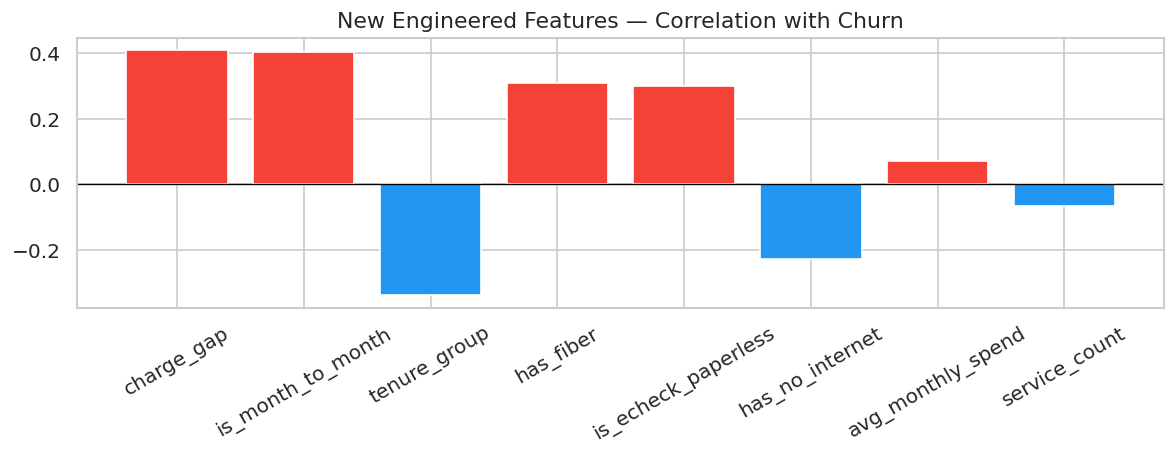

In [10]:
# ── Validate new features against Churn rate ─────────────────────────────────
NEW_FEATURES = [
    'tenure_group', 'avg_monthly_spend', 'charge_gap',
    'service_count', 'is_echeck_paperless', 'is_month_to_month',
    'has_fiber', 'has_no_internet'
]

print('── Pearson correlation of new features with Churn ──')
new_corr = df[NEW_FEATURES + ['Churn']].corr(numeric_only=True)['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(new_corr.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#F44336' if v > 0 else '#2196F3' for v in new_corr.values]
ax.bar(new_corr.index, new_corr.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('New Engineered Features — Correlation with Churn')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Encoding Categorical Variables

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# Strategy:
#   • Binary columns (Yes/No, Male/Female)  → map to 0/1 directly
#   • Ordinal column (Contract)             → ordinal encoding
#   • Nominal columns (InternetService,     → one-hot encoding (drop_first=True)
#     PaymentMethod)
# ──────────────────────────────────────────────────────────────────────────────

df_enc = df.copy()

# ── 5.1 Binary columns ────────────────────────────────────────────────────────
BINARY_YES_NO = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]
for col in BINARY_YES_NO:
    df_enc[col] = df_enc[col].map({'Yes': 1, 'No': 0})

df_enc['gender'] = df_enc['gender'].map({'Male': 1, 'Female': 0})

# ── 5.2 Ordinal encoding — Contract ──────────────────────────────────────────
CONTRACT_ORDER = [['Month-to-month', 'One year', 'Two year']]
oe = OrdinalEncoder(categories=CONTRACT_ORDER)
df_enc['Contract'] = oe.fit_transform(df_enc[['Contract']]).astype(int)
joblib.dump(oe, ARTIFACTS_DIR / 'ordinal_encoder_contract.pkl')

# ── 5.3 One-hot encoding — InternetService & PaymentMethod ───────────────────
df_enc = pd.get_dummies(
    df_enc,
    columns=['InternetService', 'PaymentMethod'],
    drop_first=True,
    dtype=int
)

print(f'Shape after encoding: {df_enc.shape}')
print('\nAll columns:')
print(df_enc.columns.tolist())

Shape after encoding: (7043, 31)

All columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'avg_monthly_spend', 'charge_gap', 'service_count', 'is_echeck_paperless', 'is_month_to_month', 'has_fiber', 'has_no_internet', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [12]:
# ── Confirm no remaining object columns ──────────────────────────────────────
obj_cols = df_enc.select_dtypes('object').columns.tolist()
assert len(obj_cols) == 0, f'Remaining object columns: {obj_cols}'

# ── Confirm no nulls ─────────────────────────────────────────────────────────
assert df_enc.isnull().sum().sum() == 0, 'Nulls found after encoding!'

print('✅ No object columns. No nulls. Ready for scaling.')

✅ No object columns. No nulls. Ready for scaling.


## 6. Scaling Numerical Features

In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# Only continuous numerical features are scaled.
# Binary (0/1) and ordinal integer columns are left as-is.
# ──────────────────────────────────────────────────────────────────────────────
SCALE_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charge_gap']

scaler = StandardScaler()
df_enc[SCALE_COLS] = scaler.fit_transform(df_enc[SCALE_COLS])

# Persist scaler for inference pipeline
joblib.dump(scaler, ARTIFACTS_DIR / 'standard_scaler.pkl')
print(f'Scaler saved → {ARTIFACTS_DIR / "standard_scaler.pkl"}')

print('\nPost-scaling statistics:')
df_enc[SCALE_COLS].describe().round(3)

Scaler saved → ../models/standard_scaler.pkl

Post-scaling statistics:


,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend,charge_gap
count,7043.000,7043.000,7043.000,7043.000,7043.000
mean,-0.000,-0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.318,-1.546,-0.998,-1.635,-1.374
25%,-0.952,-0.973,-0.830,-1.078,-0.558
50%,-0.137,0.186,-0.391,0.064,-0.370
75%,0.921,0.834,0.665,0.845,0.076
max,1.614,1.794,2.826,1.964,5.140


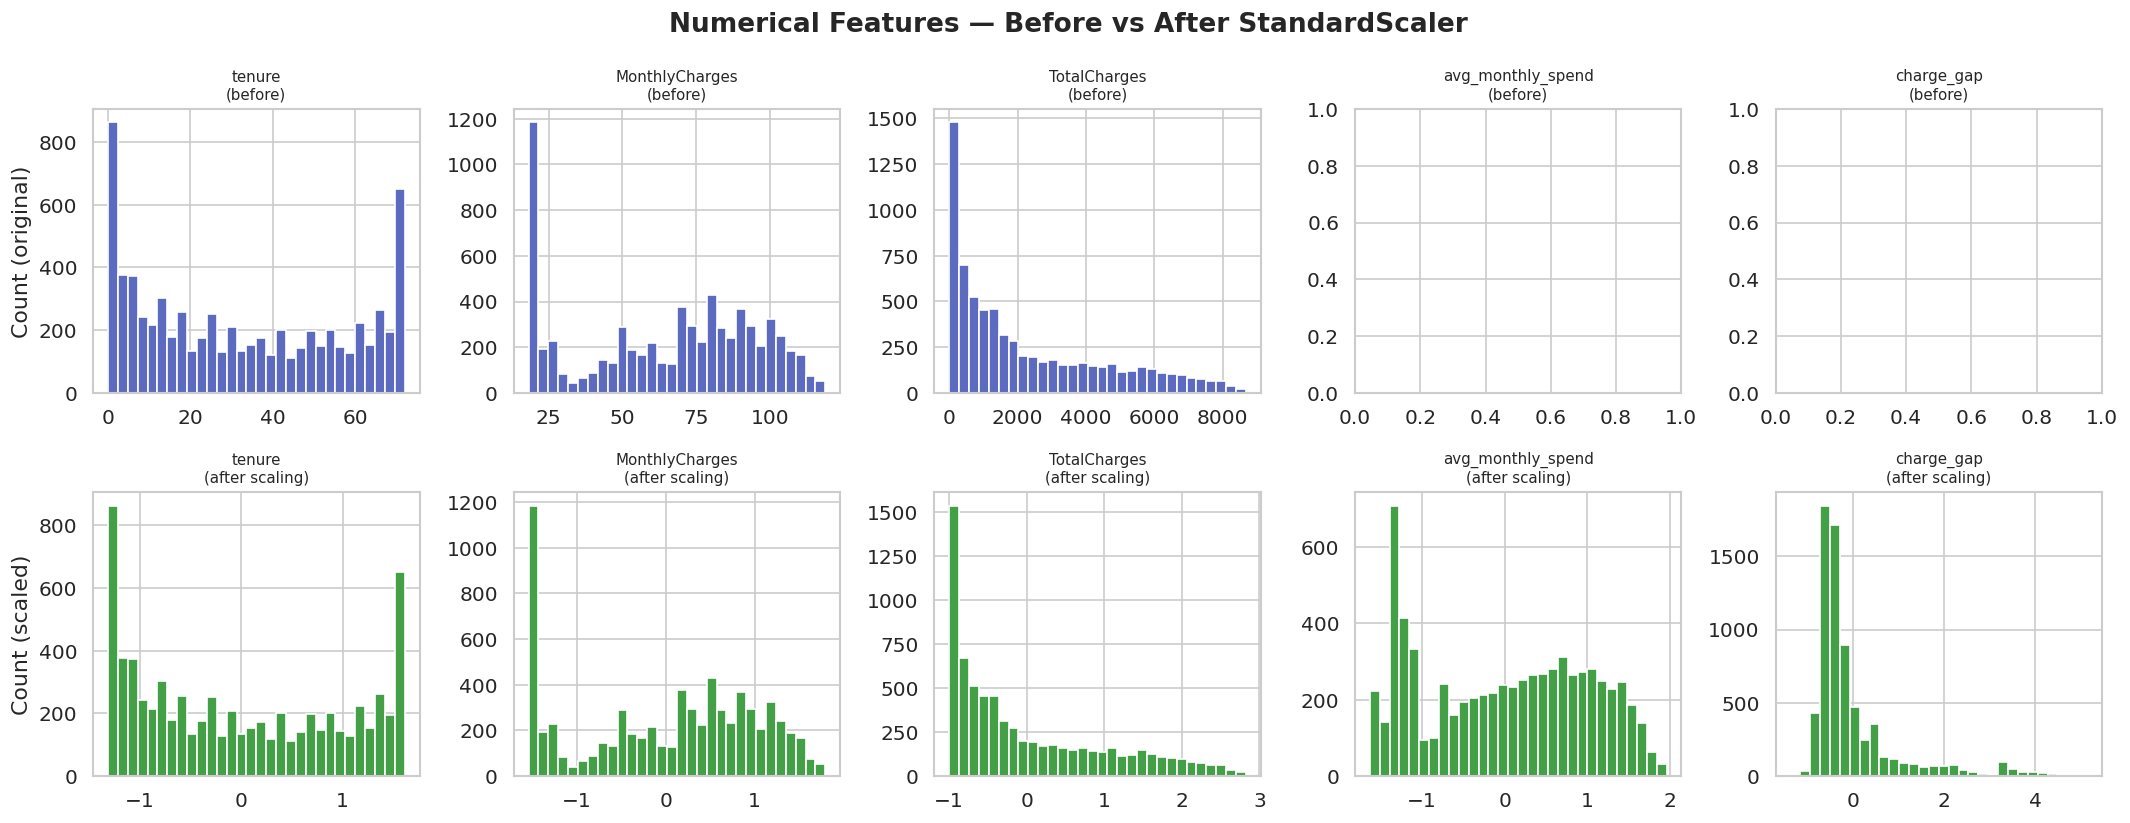

In [14]:
# ── Visual: pre vs post scaling ───────────────────────────────────────────────
fig, axes = plt.subplots(2, len(SCALE_COLS), figsize=(18, 7))

df_raw_reload = pd.read_csv('../data/raw_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_raw_reload['TotalCharges'] = pd.to_numeric(df_raw_reload['TotalCharges'], errors='coerce').fillna(0)

for i, col in enumerate(SCALE_COLS):
    raw_col = col if col in df_raw_reload.columns else None
    if raw_col:
        axes[0, i].hist(df_raw_reload[col].dropna(), bins=30, color='#5C6BC0', edgecolor='white')
    axes[0, i].set_title(f'{col}\n(before)', fontsize=9)

    axes[1, i].hist(df_enc[col], bins=30, color='#43A047', edgecolor='white')
    axes[1, i].set_title(f'{col}\n(after scaling)', fontsize=9)

axes[0, 0].set_ylabel('Count (original)')
axes[1, 0].set_ylabel('Count (scaled)')
plt.suptitle('Numerical Features — Before vs After StandardScaler', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Selection & Importance Preview

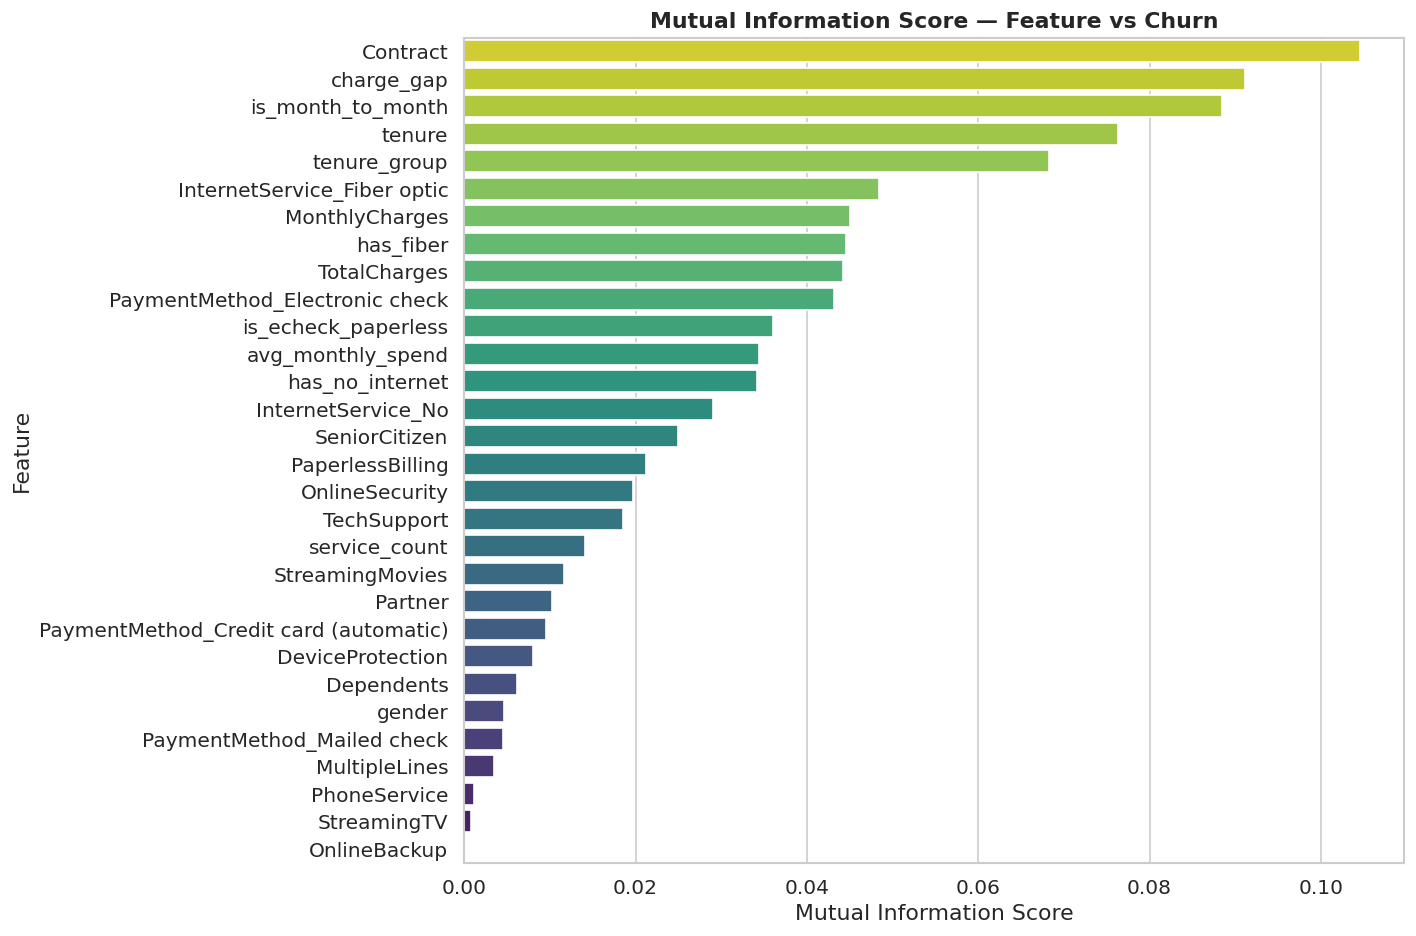

Top 10 features by Mutual Information:
                       Feature  MI_Score
                      Contract  0.104533
                    charge_gap  0.091094
             is_month_to_month  0.088486
                        tenure  0.076320
                  tenure_group  0.068286
   InternetService_Fiber optic  0.048415
                MonthlyCharges  0.044979
                     has_fiber  0.044520
                  TotalCharges  0.044161
PaymentMethod_Electronic check  0.043210


In [15]:
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

# ── 7.1 Mutual Information ────────────────────────────────────────────────────
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})\
          .sort_values('MI_Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='viridis_r', ax=ax)
ax.set_title('Mutual Information Score — Feature vs Churn', fontweight='bold')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

print('Top 10 features by Mutual Information:')
print(mi_df.head(10).to_string(index=False))

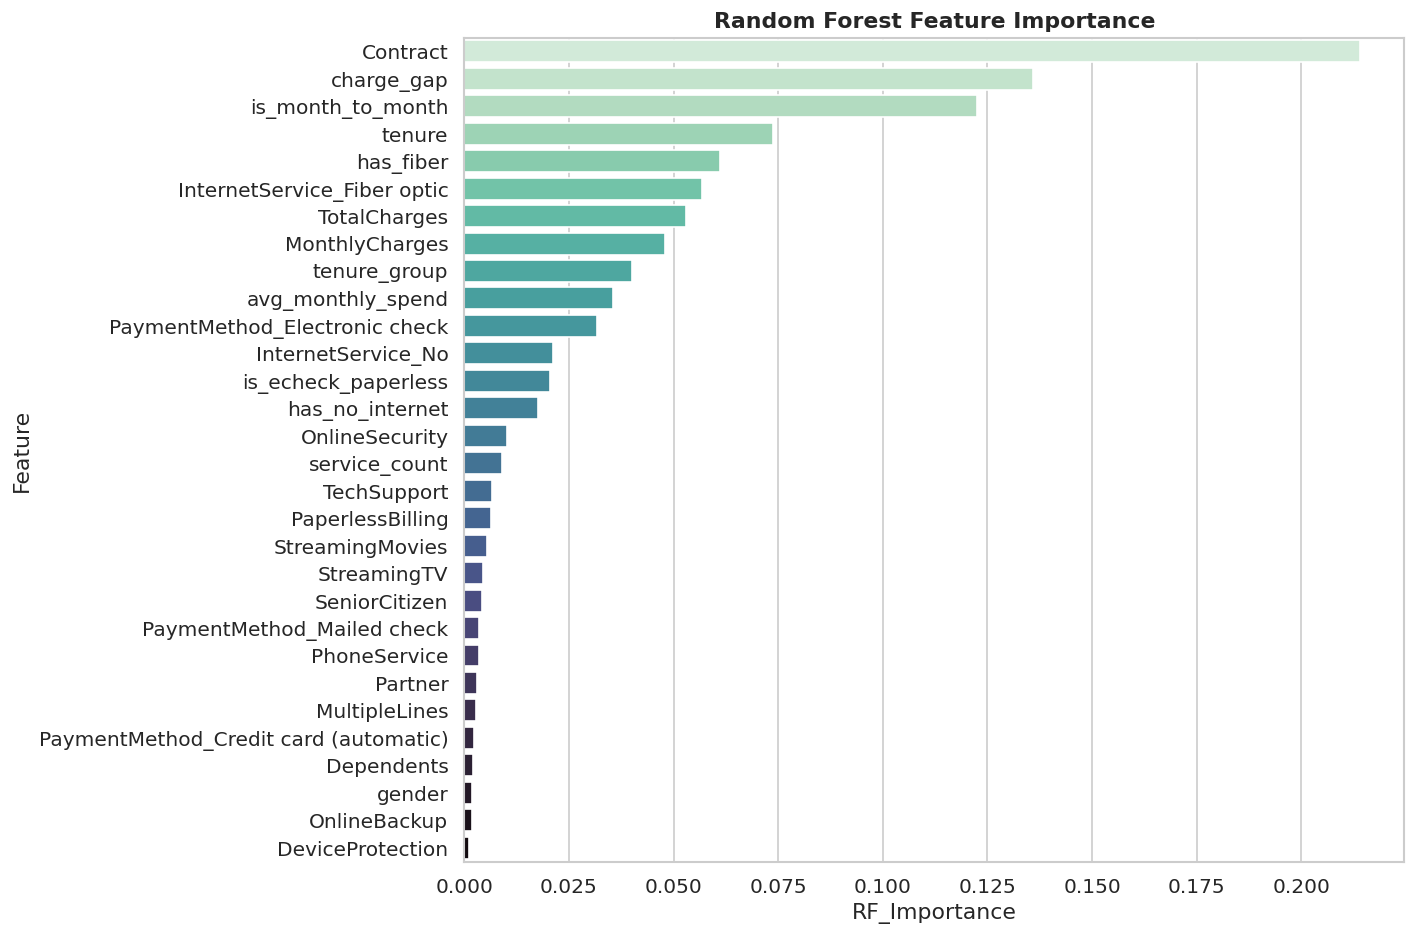

Top 10 features by RF Importance:
                    Feature  RF_Importance
                   Contract       0.213925
                 charge_gap       0.135889
          is_month_to_month       0.122567
                     tenure       0.073796
                  has_fiber       0.061069
InternetService_Fiber optic       0.056747
               TotalCharges       0.053007
             MonthlyCharges       0.047899
               tenure_group       0.040011
          avg_monthly_spend       0.035508


In [16]:
# ── 7.2 Random Forest feature importance ─────────────────────────────────────
rf_quick = RandomForestClassifier(
    n_estimators=100, max_depth=6,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf_quick.fit(X, y)

rf_imp = pd.DataFrame({'Feature': X.columns, 'RF_Importance': rf_quick.feature_importances_})\
           .sort_values('RF_Importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=rf_imp, x='RF_Importance', y='Feature', palette='mako_r', ax=ax)
ax.set_title('Random Forest Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features by RF Importance:')
print(rf_imp.head(10).to_string(index=False))

In [17]:
# ── 7.3 Combined ranking ──────────────────────────────────────────────────────
ranking = mi_df.merge(rf_imp, on='Feature')
ranking['MI_rank'] = ranking['MI_Score'].rank(ascending=False)
ranking['RF_rank'] = ranking['RF_Importance'].rank(ascending=False)
ranking['avg_rank'] = ((ranking['MI_rank'] + ranking['RF_rank']) / 2).round(1)
ranking = ranking.sort_values('avg_rank').reset_index(drop=True)

print('── Combined Feature Ranking ──')
print(ranking[['Feature', 'MI_Score', 'RF_Importance', 'avg_rank']].to_string(index=False))

# ── Features to drop (very low combined importance) ───────────────────────────
LOW_IMPORTANCE_THRESHOLD = ranking['avg_rank'].quantile(0.85)
drop_candidates = ranking[ranking['avg_rank'] > LOW_IMPORTANCE_THRESHOLD]['Feature'].tolist()
print(f'\nLow-importance drop candidates (bottom 15%): {drop_candidates}')

── Combined Feature Ranking ──
                              Feature  MI_Score  RF_Importance  avg_rank
                             Contract  0.104533       0.213925       1.0
                           charge_gap  0.091094       0.135889       2.0
                    is_month_to_month  0.088486       0.122567       3.0
                               tenure  0.076320       0.073796       4.0
          InternetService_Fiber optic  0.048415       0.056747       6.0
                            has_fiber  0.044520       0.061069       6.5
                         tenure_group  0.068286       0.040011       7.0
                       MonthlyCharges  0.044979       0.047899       7.5
                         TotalCharges  0.044161       0.053007       8.0
       PaymentMethod_Electronic check  0.043210       0.031601      10.5
                    avg_monthly_spend  0.034373       0.035508      11.0
                  is_echeck_paperless  0.036045       0.020528      12.0
                   I

## 8. Save Processed Dataset

In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# Save three versions:
#   1. Full processed dataset (all features)
#   2. Feature matrix X
#   3. Target vector y
# ──────────────────────────────────────────────────────────────────────────────

# Full
output_path = PROCESSED_DIR / 'telco_processed.csv'
df_enc.to_csv(output_path, index=False)
print(f'✅ Full processed data saved → {output_path}')

# Feature matrix
X.to_csv(PROCESSED_DIR / 'X.csv', index=False)
print(f'✅ Feature matrix (X) saved → {PROCESSED_DIR / "X.csv"}')

# Target
y.to_csv(PROCESSED_DIR / 'y.csv', index=False)
print(f'✅ Target vector (y) saved → {PROCESSED_DIR / "y.csv"}')

# Save feature column names (critical for inference consistency)
import json
feature_names = X.columns.tolist()
with open(ARTIFACTS_DIR / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
print(f'✅ Feature names saved → {ARTIFACTS_DIR / "feature_names.json"}')

✅ Full processed data saved → ../data/processed/telco_processed.csv
✅ Feature matrix (X) saved → ../data/processed/X.csv
✅ Target vector (y) saved → ../data/processed/y.csv
✅ Feature names saved → ../models/feature_names.json


In [19]:
# ── Final schema ─────────────────────────────────────────────────────────────
print(f"""
╔══════════════════════════════════════════════════════════╗
║           FEATURE ENGINEERING SUMMARY                    ║
╚══════════════════════════════════════════════════════════╝

Input shape  : {df.shape}
Output shape : {df_enc.shape}   (features = {X.shape[1]})

Transformations applied:
  ✔ TotalCharges imputed (11 rows, tenure=0 customers)
  ✔ 'No phone/internet service' collapsed → 'No'
  ✔ Binary columns mapped to 0/1
  ✔ Contract: ordinal encoded (MTM=0, 1yr=1, 2yr=2)
  ✔ InternetService & PaymentMethod: one-hot encoded
  ✔ Numerical features: StandardScaler applied

New features created:
  ✔ tenure_group       — 6-level tenure cohort
  ✔ avg_monthly_spend  — TotalCharges / (tenure+1)
  ✔ charge_gap         — MonthlyCharges - avg_monthly_spend
  ✔ service_count      — count of active add-on services
  ✔ is_echeck_paperless  — high-risk payment flag
  ✔ is_month_to_month    — highest-risk contract flag
  ✔ has_fiber            — fiber optic internet flag
  ✔ has_no_internet      — no internet service flag

Artifacts saved:
  ✔ standard_scaler.pkl
  ✔ ordinal_encoder_contract.pkl
  ✔ feature_names.json

Proceed to 03_modeling.ipynb
""")


╔══════════════════════════════════════════════════════════╗
║           FEATURE ENGINEERING SUMMARY                    ║
╚══════════════════════════════════════════════════════════╝

Input shape  : (7043, 28)
Output shape : (7043, 31)   (features = 30)

Transformations applied:
  ✔ TotalCharges imputed (11 rows, tenure=0 customers)
  ✔ 'No phone/internet service' collapsed → 'No'
  ✔ Binary columns mapped to 0/1
  ✔ Contract: ordinal encoded (MTM=0, 1yr=1, 2yr=2)
  ✔ InternetService & PaymentMethod: one-hot encoded
  ✔ Numerical features: StandardScaler applied

New features created:
  ✔ tenure_group       — 6-level tenure cohort
  ✔ avg_monthly_spend  — TotalCharges / (tenure+1)
  ✔ charge_gap         — MonthlyCharges - avg_monthly_spend
  ✔ service_count      — count of active add-on services
  ✔ is_echeck_paperless  — high-risk payment flag
  ✔ is_month_to_month    — highest-risk contract flag
  ✔ has_fiber            — fiber optic internet flag
  ✔ has_no_internet      — no inter